In this notebook I am developing methods to take songs and turn them into spectrograms, and then to save the spectrogram as a tensor. I want to take only a slice from the middle of the song.

so ill take 10 seconds before and after the middle point (very the songs are at least 20 seconds long)

So here is my plan:
1. import the song
2. downsample it to 8kz and convert it to mono
3. slice out the middle 20 seconds
4. convert this middle 20 seconds into a spectrogram
5. return this spectrogram as a tensor


UPDATE: ok so it looks like everything went well, i'm going to move my function into a python file where i can keep track of all my helper functions



In [2]:
import torchaudio.transforms as T
import torch
import numpy as np
import librosa

In [3]:
SONG_PATH = "Benson Boone - Mystical Magical.ogg"

In [34]:
def spectrogram_of_middle(song_path, sr=2**13, n_fft=2**11, hop_length=2**10):

    # Load the audio file, convert it to mono, downsample to sr
    y, sr = librosa.load(song_path, sr=sr, mono=True)

    # make sure the song is long enough

    if len(y)//sr < 20:
        raise ValueError("The song is too short to analyze. It must be at least 20 seconds long.")
    


    # Calculate the middle index
    middle_index = len(y) // 2
    
    segment = y[middle_index - sr*10:middle_index + sr*10]  # 10 seconds segment around the middle
    
    
    print(segment.shape)

    # Compute the spectrogram
    spectrogram = T.Spectrogram(n_fft=n_fft, hop_length=hop_length)(torch.tensor(segment).float())
    
    image = librosa.power_to_db(spectrogram.numpy())

    return torch.from_numpy(image)

In [ ]:
def spectrogram_of_middle(song_path, sr=2**13, n_fft=2**11, hop_length=2**10):

    # Load the audio file, convert it to mono, downsample to sr
    y, sr = librosa.load(song_path, sr=sr, mono=True)

    # make sure the song is long enough

    if len(y)//sr < 20:
        raise ValueError("The song is too short to analyze. It must be at least 20 seconds long.")
    


    # Calculate the middle index
    middle_index = len(y) // 2
    
    segment = y[middle_index - sr*10:middle_index + sr*10]  # 10 seconds segment around the middle
    
    
    print(segment.shape)

    # Compute the spectrogram
    spectrogram = T.Spectrogram(n_fft=n_fft, hop_length=hop_length)(torch.tensor(segment).float())
    
    image = librosa.power_to_db(spectrogram.numpy())

    return torch.from_numpy(image)

In [35]:
modified_spectrogram = spectrogram_of_middle(SONG_PATH)

(163840,)


In [36]:
modified_spectrogram

tensor([[ 25.4066,   3.0033,  13.5949,  ..., -14.2346,  -5.0053,  17.1445],
        [ 24.8929,  -5.1195,  10.3130,  ...,   8.1524,  10.2780,  19.3722],
        [ 23.8525,  -6.5202,  10.5618,  ...,  12.0969,   7.5674,  20.8381],
        ...,
        [ -9.0242, -35.8402, -35.8402,  ..., -35.8402, -35.8402, -13.0955],
        [ -9.0327, -35.8402, -35.8402,  ..., -35.8402, -35.8402, -13.0941],
        [ -9.0360, -35.8402, -35.8402,  ..., -35.8402, -35.8402, -13.0938]])

In [37]:
modified_spectrogram.size()

torch.Size([1025, 161])

In [38]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
# without this, Numpy and Matplotlib and Librosa all try and activate this library and it crashes. This is a workaround that the error message sugests and warns heavily agian... Oh well!

import matplotlib.pyplot as plt

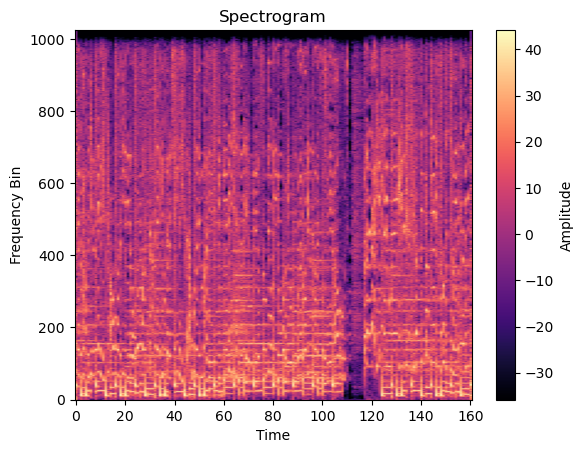

In [40]:
tensor = modified_spectrogram  # Replace with your actual tensor

# Convert to NumPy if needed
image = tensor.numpy()

# Display as image
plt.imshow(image, aspect='auto', origin='lower', cmap='magma', )  # 'magma' is good for spectrograms
plt.colorbar(label='Amplitude')
plt.xlabel('Time')
plt.ylabel('Frequency Bin')
plt.title('Spectrogram')
plt.show()